<style>
    .title { color: #2c3e50; text-align: center; border-bottom: 1px solid #eee; padding-bottom: 10px; }
    .author { font-style: italic; color: #7f8c8d; text-align: center; margin-top: 5px; }
    .author a { color: #3498db; text-decoration: none; }
</style>

<h1 class="title">Análise Fundamentalista de Ações com Python</h1>
<p class="author">
    <strong>Autor:</strong> Wellington M Santos - Data Scientist <br>
    <strong>LinkedIn:</strong> <a href="https://www.linkedin.com/in/wellington-moreira-santos/" target="_blank">wellington-moreira-santos</a>  
    <strong style='margin-left:1rem'>Email:</strong> <a href="mailto:wsantos08@hotmail.com">wsantos08@hotmail.com</a>
</p>


## Introdução
Neste projeto, utilizo Python para coletar, processar e analisar indicadores
fundamentalistas de ações listadas na B3, a bolsa de valores brasileira. O
objetivo central não é recomendar investimentos, mas demonstrar como estruturar
um pipeline de análise quantitativa a partir de dados financeiros reais,
aplicando critérios objetivos para reduzir um universo amplo de ativos a um
conjunto de candidatos que atendem a determinados padrões de qualidade e valor.

A análise fundamentalista parte do princípio de que o preço de uma ação, no
longo prazo, tende a refletir a qualidade dos fundamentos da empresa que ela
representa. Indicadores como o Preço sobre Lucro (P/L), o Retorno sobre
Patrimônio Líquido (ROE) e o Dividend Yield fornecem uma leitura objetiva sobre
valuation, rentabilidade e geração de caixa. Ao combiná-los de forma estruturada,
consigo construir um funil de seleção que traduz critérios de investimento em
operações sobre dados.

Para a coleta dos dados, utilizo a biblioteca `fundamentus`, que oferece uma
interface Python direta ao site Fundamentus (fundamentus.com.br), uma das
principais fontes públicas de indicadores fundamentalistas do mercado brasileiro.
Todo o processamento é feito com `pandas`, e as visualizações são produzidas com
`matplotlib` e `seaborn`.

Este notebook está organizado nas seguintes etapas:

1. Coleta e inspeção dos dados brutos
2. Limpeza e tratamento de inconsistências
3. Aplicação progressiva do funil de critérios
4. Ranqueamento dos candidatos selecionados
5. Análise setorial dos resultados
6. Conclusão e considerações finais

## 1. Imports e Configurações

Antes de iniciar a análise, importo as bibliotecas necessárias e defino as
configurações visuais que serão utilizadas ao longo do notebook. A biblioteca
`fundamentus` é responsável pela coleta dos dados diretamente do site
Fundamentus, enquanto `pandas` gerencia toda a estrutura tabular. Para as
visualizações, utilizo `matplotlib` e `seaborn`.

In [41]:
import warnings
warnings.filterwarnings('ignore')

import fundamentus
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler



#configurações visuais
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.figsize'  : (12, 5),
    'axes.titlesize'  : 13,
    'axes.labelsize'  : 11,
    'xtick.labelsize' : 10,
    'ytick.labelsize' : 10,
    'axes.spines.top'    : False,
    'axes.spines.right'  : False,
})

#para plotes
COR_BARRA    = '#2c3e50'
COR_MEDIA    = '#e74c3c'
COR_GRID     = '#eeeeee'
FONTE_TITULO = {'fontsize': 11, 'fontweight': 'bold', 'color': '#2c3e50'}
FONTE_EIXO   = {'fontsize': 9,  'color': '#555555'}

print("Bibliotecas carregadas com sucesso.")

Bibliotecas carregadas com sucesso.


## 2. Coleta e Inspeção dos Dados

Utilizo a função `get_resultado_raw()` da biblioteca `fundamentus` para obter um
snapshot atual de todos os papéis disponíveis na B3 com seus respectivos
indicadores fundamentalistas. O retorno é um DataFrame onde cada linha
representa um papel e cada coluna representa um múltiplo ou indicador.

É importante compreender que os dados coletados representam um momento
específico no tempo. Não se trata de uma série histórica, mas de uma fotografia
do mercado no instante da consulta. Isso tem implicações diretas na
interpretação dos resultados, que discuto ao longo do notebook.

In [2]:
df_raw = fundamentus.get_resultado_raw()

print(f"Dimensões do DataFrame: {df_raw.shape}")
print(f"Total de papéis coletados: {df_raw.shape[0]}")
print(f"\nColunas disponíveis:\n{list(df_raw.columns)}")

Dimensões do DataFrame: (994, 21)
Total de papéis coletados: 994

Colunas disponíveis:
['Cotação', 'P/L', 'P/VP', 'PSR', 'Div.Yield', 'P/Ativo', 'P/Cap.Giro', 'P/EBIT', 'P/Ativ Circ.Liq', 'EV/EBIT', 'EV/EBITDA', 'Mrg Bruta', 'Mrg Ebit', 'Mrg. Líq.', 'Liq. Corr.', 'ROIC', 'ROE', 'Liq.2meses', 'Patrim. Líq', 'Dív.Líq/ Patrim.', 'Cresc. Rec.5a']


### 2.1 Inspeção Inicial

Antes de qualquer processamento, inspeciono a estrutura dos dados para
entender o que foi coletado: tipos de cada coluna, presença de valores nulos
e a distribuição geral dos indicadores. Essa etapa é essencial para tomar
decisões informadas na fase de limpeza.

In [3]:
#visao geral :: primeiros e ultimos 5 registros
df_raw

Multiples,Cotação,P/L,P/VP,PSR,Div.Yield,P/Ativo,P/Cap.Giro,P/EBIT,P/Ativ Circ.Liq,EV/EBIT,...,Mrg Bruta,Mrg Ebit,Mrg. Líq.,Liq. Corr.,ROIC,ROE,Liq.2meses,Patrim. Líq,Dív.Líq/ Patrim.,Cresc. Rec.5a
papel,,,,,,,,,,,,,,,,,,,,,
AALR3,3.24,-6.13,0.46,0.398,0.0000,0.163,112.89,5.72,-0.44,9.93,...,"26,83%",0.0696,-0.0570,1.01,0.0313,-0.0754,183141.0,1.066930e+09,0.34,0.0234
ABCB3,0.00,0.00,0.00,0.000,0.0000,0.000,0.00,0.00,0.00,0.00,...,"0,00%",0.0000,0.0000,0.00,0.0000,0.1408,0.0,7.147590e+09,0.00,0.0566
ABCB4,24.62,6.37,0.90,0.000,0.0998,0.000,0.00,0.00,0.00,0.00,...,"0,00%",0.0000,0.0000,0.00,0.0000,0.1408,20369800.0,7.147590e+09,0.00,0.0566
ABEV3,16.64,16.84,2.91,2.974,0.0516,1.837,224.37,12.81,-28.81,12.01,...,"51,48%",0.2321,0.1822,1.03,0.2004,0.1728,466210000.0,9.012580e+10,-0.18,0.0458
ABYA3,4.91,-214.80,1.76,2.055,0.0000,0.527,1.98,19.96,-2.75,33.67,...,"32,03%",0.1029,-0.0096,2.09,0.0278,-0.0082,0.0,2.920600e+08,1.21,0.1641
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
WLMM4,18.21,8.36,0.84,0.226,0.1117,0.421,1.52,5.09,4.79,6.92,...,"13,02%",0.0443,0.0269,1.89,0.1032,0.1000,30292.2,7.931650e+08,0.30,0.1657
WMBY3,25.39,-19.30,2.87,0.836,0.0000,0.182,1.20,8.62,-1.50,25.02,...,"26,91%",0.0970,-0.0705,1.44,0.0239,-0.1486,0.0,2.124390e+08,5.46,-0.1448
WSON33,67.00,8.07,0.98,1.067,0.0000,0.400,13.41,2.42,-0.89,5.08,...,"52,58%",0.4414,0.1358,1.26,0.1836,0.1217,0.0,2.148530e+09,1.08,0.0523


In [4]:
# tipo de dados
df_raw.dtypes

Multiples
Cotação             float64
P/L                 float64
P/VP                float64
PSR                 float64
Div.Yield           float64
P/Ativo             float64
P/Cap.Giro          float64
P/EBIT              float64
P/Ativ Circ.Liq     float64
EV/EBIT             float64
EV/EBITDA           float64
Mrg Bruta               str
Mrg Ebit            float64
Mrg. Líq.           float64
Liq. Corr.          float64
ROIC                float64
ROE                 float64
Liq.2meses          float64
Patrim. Líq         float64
Dív.Líq/ Patrim.        str
Cresc. Rec.5a       float64
dtype: object

In [5]:
#valores nulos
df_raw.isnull().sum()

Multiples
Cotação             0
P/L                 0
P/VP                0
PSR                 0
Div.Yield           0
P/Ativo             0
P/Cap.Giro          0
P/EBIT              0
P/Ativ Circ.Liq     0
EV/EBIT             0
EV/EBITDA           0
Mrg Bruta           0
Mrg Ebit            0
Mrg. Líq.           0
Liq. Corr.          0
ROIC                0
ROE                 0
Liq.2meses          0
Patrim. Líq         0
Dív.Líq/ Patrim.    0
Cresc. Rec.5a       0
dtype: int64

In [6]:
#estatísticas descritivas
df_raw.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
Multiples,,,,,,,,
Cotação,994.0,6.380000e+01,4.901600e+02,0.000000e+00,3.370000e+00,1.108000e+01,2.946000e+01,1.008190e+04
P/L,994.0,-1.210300e+02,4.222430e+03,-1.329930e+05,-1.300000e-01,5.200000e+00,1.320000e+01,2.803570e+03
P/VP,994.0,1.460220e+03,3.177301e+04,-3.591500e+02,9.000000e-02,9.400000e-01,1.960000e+00,7.237080e+05
PSR,994.0,6.505500e+02,2.008114e+04,-9.596100e+02,3.000000e-02,5.400000e-01,1.520000e+00,6.331110e+05
Div.Yield,994.0,4.000000e-02,3.900000e-01,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e-02,1.203000e+01
P/Ativo,994.0,2.770000e+00,3.375000e+01,0.000000e+00,7.000000e-02,3.500000e-01,7.700000e-01,9.465700e+02
P/Cap.Giro,994.0,-2.582000e+02,8.438140e+03,-2.659860e+05,-1.000000e-02,7.000000e-01,4.060000e+00,3.608020e+03
P/EBIT,994.0,-1.369000e+01,2.829300e+02,-7.214410e+03,0.000000e+00,2.210000e+00,7.500000e+00,6.737500e+02
P/Ativ Circ.Liq,994.0,-2.695100e+02,8.436670e+03,-2.659860e+05,-1.330000e+00,-1.100000e-01,0.000000e+00,2.353100e+02


### 2.2 Distribuições dos Indicadores Brutos

Visualizo as distribuições dos principais indicadores antes de qualquer
filtragem. Esse passo revela algo esperado em dados financeiros reais: a
presença de valores extremos e assimetrias pronunciadas. Empresas com
prejuízo, por exemplo, apresentam P/L negativo, o que distorce a escala
dos gráficos e confirma a necessidade de tratamento antes da análise.

In [44]:
# indicadores = ['P/L', 'P/VP', 'ROE', 'Div.Yield', 'ROIC', 'EV/EBITDA']

# fig, axes = plt.subplots(2, 3, figsize=(15, 8))
# axes = axes.flatten()

# for i, col in enumerate(indicadores):
#     ax = axes[i]
#     dados = df_raw[col].replace([float('inf'), float('-inf')], pd.NA).dropna()
#     ax.hist(dados, bins=50, color=COR_BARRA, edgecolor='none', alpha=0.85)

#     #medias
#     media = dados.mean()
#     ax.axvline(media, color=COR_MEDIA, linewidth=1.2, linestyle='--',
#                label=f'Média: {media:.2f}')

#     #grids
#     ax.yaxis.grid(True, color=COR_GRID, linewidth=0.8, zorder=0)
#     ax.set_axisbelow(True)

#     ax.set_title(col, **FONTE_TITULO)
#     ax.set_xlabel('Valor', **FONTE_EIXO)
#     ax.set_ylabel('Frequência', **FONTE_EIXO)
#     ax.legend(fontsize=8, framealpha=0.5)

#     #remover bordas :: superior e direita
#     ax.spines['top'].set_visible(False)
#     ax.spines['right'].set_visible(False)
#     ax.spines['left'].set_color('#cccccc')
#     ax.spines['bottom'].set_color('#cccccc')

# fig.suptitle(
#     'Distribuição dos Indicadores Fundamentalistas',
#     fontsize=14, fontweight='bold', color='#2c3e50',
#     x=0.01, y=1.01, ha='left'
# )
# fig.text(
#     0.01, -0.01,
#     'Intervalo exibido: percentis 5 a 95.\nFonte: fundamentus.com.br',
#     fontsize=8, color='#888888', style='italic'
# )

# plt.tight_layout()
# plt.show()

Outliers extremos comprimem toda a distribuição em uma única barra, a seguir uma solução com corte percentil para a visualização

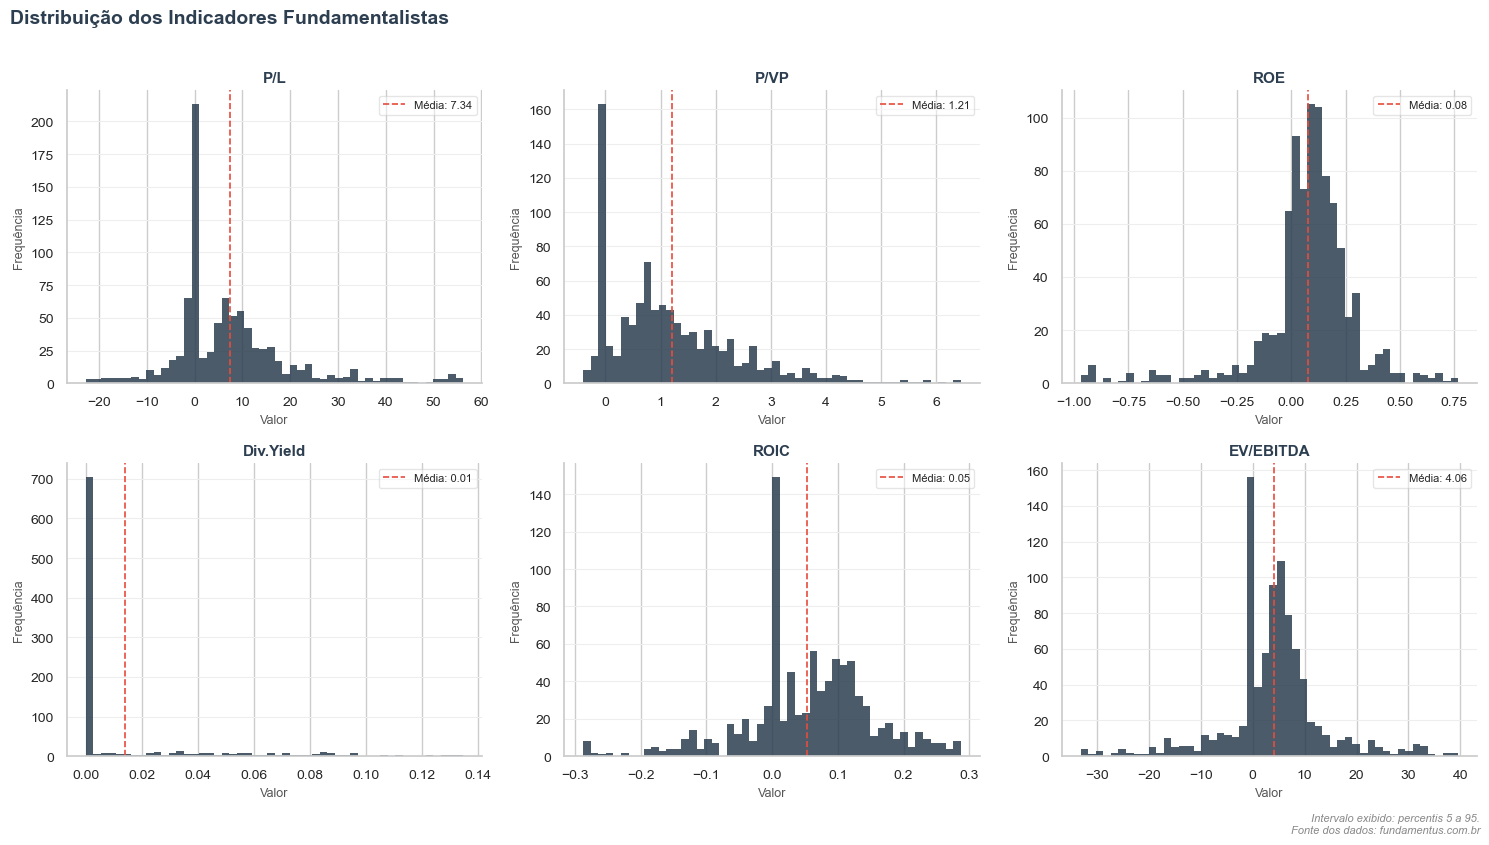

In [47]:
indicadores = ['P/L', 'P/VP', 'ROE', 'Div.Yield', 'ROIC', 'EV/EBITDA']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(indicadores):
    ax = axes[i]
    dados = df_raw[col].replace([float('inf'), float('-inf')], pd.NA).dropna()

    #cortes percentis para visualizacao
    p05 = dados.quantile(0.05)
    p95 = dados.quantile(0.95)
    dados_viz = dados[(dados >= p05) & (dados <= p95)]

    ax.hist(dados_viz, bins=50, color=COR_BARRA, edgecolor='none', alpha=0.85)

    #medias
    media = dados_viz.mean()
    ax.axvline(media, color=COR_MEDIA, linewidth=1.2, linestyle='--',
               label=f'Média: {media:.2f}')

    #grids
    ax.yaxis.grid(True, color=COR_GRID, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)

    ax.set_title(col, **FONTE_TITULO)
    ax.set_xlabel('Valor', **FONTE_EIXO)
    ax.set_ylabel('Frequência', **FONTE_EIXO)
    ax.legend(fontsize=8, framealpha=0.5)

    #remover bordas :: superior e direita
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#cccccc')
    ax.spines['bottom'].set_color('#cccccc')

fig.suptitle(
    'Distribuição dos Indicadores Fundamentalistas',
    fontsize=14, fontweight='bold', color='#2c3e50',
    x=0.01, y=1.01, ha='left'
)
fig.text(
    0.99, -0.02,
    'Intervalo exibido: percentis 5 a 95.\nFonte dos dados: fundamentus.com.br',
    fontsize=8, color='#888888', style='italic', ha='right'
)

plt.tight_layout()
plt.show()

## 3. Limpeza e Pré-processamento

As distribuições observadas na seção anterior confirmam o que é esperado em
dados financeiros reais: o universo bruto contém inconsistências que precisam
ser tratadas antes de qualquer análise. Empresas com patrimônio líquido
negativo, liquidez nula ou indicadores matematicamente indefinidos não
representam candidatos viáveis para o tipo de análise que proponho aqui, e
sua presença distorceria qualquer critério de seleção subsequente.

Nesta seção, aplico um conjunto de filtros de sanidade, distintos dos critérios
fundamentalistas que virão na próxima etapa. O objetivo aqui não é selecionar
boas empresas, mas remover registros que comprometem a integridade da análise.

### 3.1 Remoção de Papéis sem Liquidez

O primeiro filtro elimina papéis com liquidez média de dois meses igual a zero.
Ações sem liquidez não possuem mercado ativo, o que torna qualquer análise de
valuation irrelevante na prática: de nada adianta identificar uma ação barata
se não é possível comprá-la ou vendê-la no mercado.

In [10]:
#total inicial
df_raw.shape[0]

994

In [11]:
#liquidez 
df_raw[df_raw['Liq.2meses']>0]

Multiples,Cotação,P/L,P/VP,PSR,Div.Yield,P/Ativo,P/Cap.Giro,P/EBIT,P/Ativ Circ.Liq,EV/EBIT,...,Mrg Bruta,Mrg Ebit,Mrg. Líq.,Liq. Corr.,ROIC,ROE,Liq.2meses,Patrim. Líq,Dív.Líq/ Patrim.,Cresc. Rec.5a
papel,,,,,,,,,,,,,,,,,,,,,
AALR3,3.24,-6.13,0.46,0.398,0.0000,0.163,112.89,5.72,-0.44,9.93,...,"26,83%",0.0696,-0.0570,1.01,0.0313,-0.0754,1.831410e+05,1.066930e+09,0.34,0.0234
ABCB4,24.62,6.37,0.90,0.000,0.0998,0.000,0.00,0.00,0.00,0.00,...,"0,00%",0.0000,0.0000,0.00,0.0000,0.1408,2.036980e+07,7.147590e+09,0.00,0.0566
ABEV3,16.64,16.84,2.91,2.974,0.0516,1.837,224.37,12.81,-28.81,12.01,...,"51,48%",0.2321,0.1822,1.03,0.2004,0.1728,4.662100e+08,9.012580e+10,-0.18,0.0458
ADHM3,1.56,-4.09,-1.29,770.924,0.0000,105.126,-1.43,-5.69,-1.27,-5.69,...,"100,00%",-135.4850,-188.6060,0.00,5.2170,0.3147,2.064000e+03,-1.977600e+07,0.00,0.4348
AERI3,2.34,-0.15,-0.17,0.227,0.0000,0.096,-0.80,-0.33,-0.07,-4.51,...,"-6,13%",-0.6950,-1.4732,0.69,-0.3147,1.1294,1.366390e+05,-8.364560e+08,-2.23,-0.2896
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
WHRL4,4.00,18.30,3.13,0.486,0.1374,0.611,-9.86,4.92,-3.91,5.01,...,"18,76%",0.0989,0.0268,0.91,0.2870,0.1712,6.513560e+04,1.918220e+09,0.06,0.0373
WIZC3,7.45,6.13,1.73,0.885,0.0844,0.493,32.57,1.77,-2.46,1.76,...,"61,24%",0.5003,0.2647,1.06,0.3487,0.2826,3.746800e+06,6.873690e+08,-0.01,0.1384
WLMM3,20.69,9.50,0.95,0.256,0.0894,0.478,1.73,5.78,5.44,7.61,...,"13,02%",0.0443,0.0269,1.89,0.1032,0.1000,1.129980e+03,7.931650e+08,0.30,0.1657


In [12]:
total_inicial = len(df_raw)

df = df_raw[df_raw['Liq.2meses'] > 0].copy()

print(f"Papéis removidos por liquidez zero : {total_inicial - len(df)}")
print(f"Papéis restantes                   : {len(df)}")

Papéis removidos por liquidez zero : 591
Papéis restantes                   : 403


### 3.2 Remoção de Papéis com Patrimônio Líquido Negativo

Patrimônio líquido negativo indica que o passivo da empresa supera seus ativos,
uma situação de insolvência técnica. Indicadores como P/VP e ROE perdem o
significado analítico nesse contexto, pois seus sinais se invertem e a
interpretação convencional deixa de ser válida.

In [13]:
antes = len(df)

df = df[df['Patrim. Líq'] > 0]

print(f"Papéis removidos por PL negativo : {antes - len(df)}")
print(f"Papéis restantes                 : {len(df)}")

Papéis removidos por PL negativo : 46
Papéis restantes                 : 357


### 3.3 Remoção de Valores Infinitos e Nulos

Alguns indicadores podem assumir valores infinitos quando o denominador da
fórmula é zero, por exemplo, um P/L calculado sobre lucro zero. Esses registros
são substituídos por nulo e removidos para garantir que os filtros numéricos
subsequentes operem sobre dados válidos.

In [14]:
antes = len(df)

df = df.replace([float('inf'), float('-inf')], pd.NA)
df = df.dropna(subset=['P/L', 'P/VP', 'ROE', 'Div.Yield', 'ROIC', 'EV/EBITDA'])

print(f"Papéis removidos por nulos/infinitos : {antes - len(df)}")
print(f"Papéis restantes                     : {len(df)}")

Papéis removidos por nulos/infinitos : 0
Papéis restantes                     : 357


O resultado zero nesta etapa não é surpreendente. Os filtros anteriores,
ao exigirem liquidez e patrimônio líquido positivos, já eliminaram os casos
que tipicamente geram valores indefinidos nos indicadores derivados.

### 3.4 Resumo da Limpeza

Consolido abaixo o impacto de cada etapa de limpeza sobre o universo de papéis,
do total bruto coletado até o conjunto saneado que será utilizado na análise.

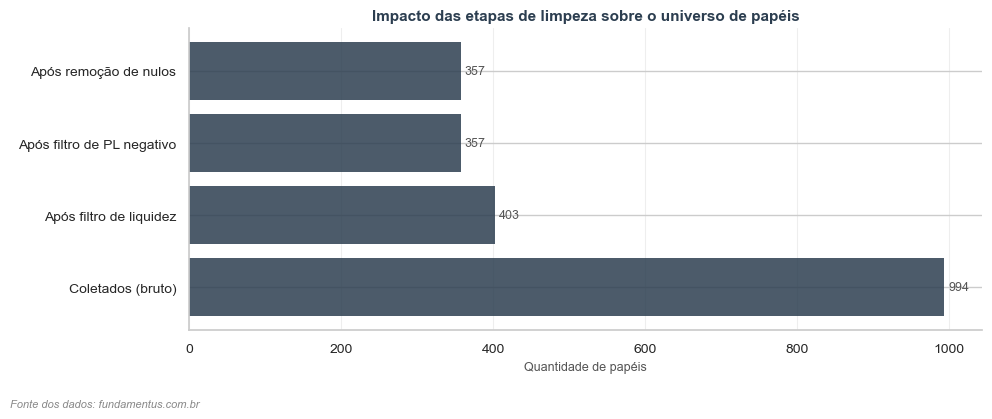

In [48]:
etapas = {
    'Coletados (bruto)'          : 994,
    'Após filtro de liquidez'    : 403,
    'Após filtro de PL negativo' : 357,
    'Após remoção de nulos'      : 357,
}

fig, ax = plt.subplots(figsize=(10, 4))

barras = ax.barh(
    list(etapas.keys()),
    list(etapas.values()),
    color=COR_BARRA, alpha=0.85, edgecolor='none'
)

for barra in barras:
    largura = barra.get_width()
    ax.text(largura + 5, barra.get_y() + barra.get_height() / 2,
            f'{int(largura)}', va='center', fontsize=9, color='#555555')

ax.set_xlabel('Quantidade de papéis', **FONTE_EIXO)
ax.set_title('Impacto das etapas de limpeza sobre o universo de papéis',
             **FONTE_TITULO)
ax.xaxis.grid(True, color=COR_GRID, linewidth=0.8)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')

fig.text(0.01, -0.04, 'Fonte dos dados: fundamentus.com.br',
         fontsize=8, color='#888888', style='italic')

plt.tight_layout()
plt.show()

## 4. Funil de Critérios Fundamentalistas

Com o universo saneado, inicio a aplicação dos critérios de seleção
fundamentalistas. A lógica do funil é progressiva: cada critério é aplicado
sobre o resultado do anterior, e o impacto de cada etapa é registrado
individualmente. Essa abordagem permite entender a contribuição de cada filtro
na redução do universo e justifica as escolhas de forma transparente.

Os critérios adotados são inspirados em abordagens clássicas de value investing,
adaptadas para o mercado brasileiro. Não representam uma recomendação de
investimento, mas sim um exercício analítico estruturado sobre dados reais.

### 4.1 Critério 1: Preço sobre Lucro (P/L)

O P/L relaciona o preço de mercado da ação ao lucro por ação gerado pela
empresa. Um P/L positivo indica que a empresa é lucrativa. Valores muito
elevados podem sinalizar sobrevalorizaçao, enquanto valores entre 0 e 15
são frequentemente associados a empresas com preço atrativo em relação
ao lucro gerado.

Elimino também empresas com P/L negativo, que indica prejuízo no período.

In [16]:
df.sample(3)

Multiples,Cotação,P/L,P/VP,PSR,Div.Yield,P/Ativo,P/Cap.Giro,P/EBIT,P/Ativ Circ.Liq,EV/EBIT,...,Mrg Bruta,Mrg Ebit,Mrg. Líq.,Liq. Corr.,ROIC,ROE,Liq.2meses,Patrim. Líq,Dív.Líq/ Patrim.,Cresc. Rec.5a
papel,,,,,,,,,,,,,,,,,,,,,
CEEB5,43.01,6.02,1.39,0.590,0.1347,0.299,4.71,2.54,-0.54,6.74,...,"28,41%",0.2319,0.0979,1.39,0.1338,0.2308,317.59,8.110000e+09,2.30,0.0686
AALR3,3.24,-6.13,0.46,0.398,0.0000,0.163,112.89,5.72,-0.44,9.93,...,"26,83%",0.0696,-0.0570,1.01,0.0313,-0.0754,183141.00,1.066930e+09,0.34,0.0234
WLMM4,18.21,8.36,0.84,0.226,0.1117,0.421,1.52,5.09,4.79,6.92,...,"13,02%",0.0443,0.0269,1.89,0.1032,0.1000,30292.20,7.931650e+08,0.30,0.1657


In [17]:
#p/l < 0
df[df['P/L'] < 0 ].shape[0]

70

In [18]:
#p/l > 0
df[df['P/L'] > 0 ].shape[0]

285

In [19]:
#p/l <= 15
df[df['P/L'] <= 15 ].shape[0]

278

In [20]:
#p/l >0 e <= 15
df[(df['P/L'] > 0) & (df['P/L'] <= 15)].shape[0]

206

In [21]:
antes = len(df)

df = df[df['P/L'].between(0,15, inclusive='right')]

print(f"Papéis removidos pelo critério P/L  : {antes - len(df)}")
print(f"Papéis restantes                    : {len(df)}")

Papéis removidos pelo critério P/L  : 151
Papéis restantes                    : 206


### 4.2 Critério 2: Preço sobre Valor Patrimonial (P/VP)

O P/VP compara o preço de mercado da ação ao valor contábil do patrimônio
líquido por ação. Um P/VP abaixo de 1 indica que o mercado precifica a empresa
abaixo do seu valor patrimonial, o que pode representar uma oportunidade de
valor. Adoto o teto de 3 para não excluir empresas de alta qualidade que
naturalmente negociam com prêmio sobre o patrimônio.

In [22]:
#pvp > 0
df[df['P/VP'] > 0 ].shape[0]

206

In [23]:
#pvp <= 3
df[df['P/VP'] <= 3 ].shape[0]

192

In [24]:
# pvp > 0 e <= 3
df[(df['P/VP'] > 0) & (df['P/VP'] <= 3)].shape[0]

192

In [25]:
antes = len(df)

df = df[ df['P/VP'].between(0,3, inclusive='right')]

print(f"Papéis removidos pelo critério P/VP : {antes - len(df)}")
print(f"Papéis restantes                    : {len(df)}")

Papéis removidos pelo critério P/VP : 14
Papéis restantes                    : 192


### 4.3 Critério 3: Retorno sobre Patrimônio Líquido (ROE)

O ROE mede a eficiência com que a empresa utiliza o capital dos acionistas
para gerar lucro. Adoto um piso de 10% como critério mínimo de qualidade,
valor frequentemente utilizado como referência para separar empresas com
rentabilidade consistente daquelas com retorno medíocre ou negativo.

In [26]:
antes = len(df)

df = df[df['ROE'] >= 0.10]

print(f"Papéis removidos pelo critério ROE  : {antes - len(df)}")
print(f"Papéis restantes                    : {len(df)}")

Papéis removidos pelo critério ROE  : 42
Papéis restantes                    : 150


### 4.4 Critério 4: Liquidez Mínima

Reforço o critério de liquidez com um piso absoluto. Exijo que o volume médio
negociado nos últimos dois meses seja superior a R$ 100.000, garantindo que
os papéis selecionados tenham mercado ativo suficiente para operações práticas.

In [27]:
antes = len(df)

df = df[df['Liq.2meses'] >= 100_000]

print(f"Papéis removidos pelo critério Liquidez : {antes - len(df)}")
print(f"Papéis restantes                        : {len(df)}")

Papéis removidos pelo critério Liquidez : 42
Papéis restantes                        : 108


### 4.5 Resumo do Funil

Consolido abaixo o impacto acumulado de cada critério fundamentalista sobre
o universo saneado. A visualização deixa evidente como cada filtro contribui
para a convergência do universo amplo a um conjunto restrito de candidatos.

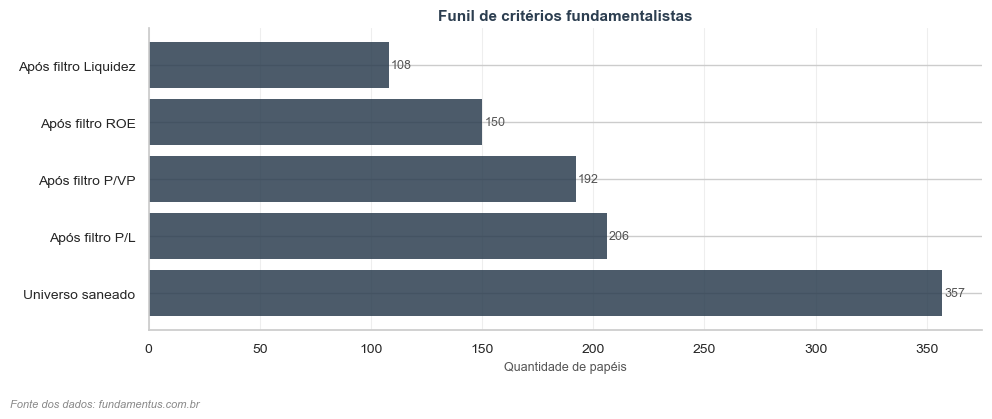

In [49]:
funil = {
    'Universo saneado'     : 357,
    'Após filtro P/L'      : 206,
    'Após filtro P/VP'     : 192,
    'Após filtro ROE'      : 150,
    'Após filtro Liquidez' : 108,
}

fig, ax = plt.subplots(figsize=(10, 4))

barras = ax.barh(
    list(funil.keys()),
    list(funil.values()),
    color=COR_BARRA, alpha=0.85, edgecolor='none'
)

for barra in barras:
    largura = barra.get_width()
    ax.text(largura + 1, barra.get_y() + barra.get_height() / 2,
            f'{int(largura)}', va='center', fontsize=9, color='#555555')

ax.set_xlabel('Quantidade de papéis', **FONTE_EIXO)
ax.set_title('Funil de critérios fundamentalistas',
             **FONTE_TITULO)
ax.xaxis.grid(True, color=COR_GRID, linewidth=0.8)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')

fig.text(0.01, -0.04, 'Fonte dos dados: fundamentus.com.br',
         fontsize=8, color='#888888', style='italic')

plt.tight_layout()
plt.show()

In [29]:
df

Multiples,Cotação,P/L,P/VP,PSR,Div.Yield,P/Ativo,P/Cap.Giro,P/EBIT,P/Ativ Circ.Liq,EV/EBIT,...,Mrg Bruta,Mrg Ebit,Mrg. Líq.,Liq. Corr.,ROIC,ROE,Liq.2meses,Patrim. Líq,Dív.Líq/ Patrim.,Cresc. Rec.5a
papel,,,,,,,,,,,,,,,,,,,,,
ABCB4,24.62,6.37,0.90,0.000,0.0998,0.000,0.00,0.00,0.00,0.00,...,"0,00%",0.0000,0.0000,0.00,0.0000,0.1408,20369800.0,7.147590e+09,0.00,0.0566
ALLD3,5.42,1.52,0.34,0.095,0.5566,0.153,0.50,3.55,0.88,4.47,...,"11,75%",0.0268,0.0626,1.74,0.0781,0.2227,2185740.0,1.537550e+09,0.09,-0.0144
ALPA4,13.26,14.63,2.62,1.926,0.1354,1.441,7.12,10.59,46.86,11.15,...,"52,49%",0.1819,0.1315,1.73,0.1700,0.1790,26477800.0,3.458800e+09,0.14,0.0369
ALUP11,32.60,9.64,1.16,2.426,0.0331,0.313,1.86,3.94,-0.81,7.36,...,"66,96%",0.6153,0.3580,3.30,0.0946,0.1200,32901400.0,9.286800e+09,1.00,-0.0034
ALUP4,10.28,9.12,1.09,2.295,0.0350,0.296,1.76,3.73,-0.77,7.15,...,"66,96%",0.6153,0.3580,3.30,0.0946,0.1200,170341.0,9.286800e+09,1.00,-0.0034
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
VIVA3,21.21,8.56,1.65,1.624,0.0329,1.071,2.23,6.76,3.80,7.03,...,"69,91%",0.2403,0.1897,4.14,0.1748,0.1931,69292200.0,3.030290e+09,0.07,0.1820
VLID3,17.54,5.89,0.84,0.715,0.0961,0.472,1.76,4.33,12.58,4.55,...,"34,81%",0.1649,0.1248,2.32,0.1505,0.1422,8002780.0,1.714470e+09,0.04,-0.0081
VTRU3,13.25,1.78,0.53,0.866,0.0019,0.286,2.66,2.31,-1.10,4.02,...,"66,28%",0.3742,0.4863,2.13,0.1479,0.2995,13329000.0,3.722430e+09,0.39,0.1259


## 5. Ranqueamento dos Candidatos

Com o universo reduzido a 108 papéis, passo para a etapa de ranqueamento.
O objetivo é ordenar os candidatos por um score composto que combina os
principais indicadores de qualidade e valor utilizados no funil. Dessa forma,
em vez de uma lista não ordenada, obtenho uma hierarquia que reflete, de forma
quantitativa, quais papéis apresentam o melhor conjunto de fundamentos dentro
dos critérios adotados.

O score é construído a partir da normalização individual de cada indicador
para uma escala entre 0 e 1, seguida de uma média ponderada. A normalização
garante que indicadores em escalas distintas contribuam de forma equilibrada
para o resultado final.

### 5.1 Construção do Score Composto

Utilizo quatro indicadores no score, com os seguintes pesos e direções:

| Indicador  | Peso | Direção         | Justificativa                              |
|------------|------|-----------------|--------------------------------------------|
| ROE        | 30%  | Maior é melhor  | Mede qualidade e eficiência do negócio     |
| P/L        | 30%  | Menor é melhor  | Menor preço relativo ao lucro é preferível |
| P/VP       | 20%  | Menor é melhor  | Menor preço relativo ao patrimônio         |
| Div.Yield  | 20%  | Maior é melhor  | Remuneração ao acionista                   |

Para indicadores onde menor é melhor, inverto a normalização subtraindo
o valor normalizado de 1, de forma que o score final sempre aponte na
direção correta: quanto maior, melhor.

In [ ]:
df_score = df.copy()
scaler   = MinMaxScaler()

#normalização
df_score['norm_roe'] = scaler.fit_transform(df_score[['ROE']])
df_score['norm_pl']  = 1 - scaler.fit_transform(df_score[['P/L']])
df_score['norm_pvp'] = 1 - scaler.fit_transform(df_score[['P/VP']])
df_score['norm_dy']  = scaler.fit_transform(df_score[['Div.Yield']])

#score composto
df_score['score'] = (
    df_score['norm_roe'] * 0.30 +
    df_score['norm_pl']  * 0.30 +
    df_score['norm_pvp'] * 0.20 +
    df_score['norm_dy']  * 0.20
)

print(f"Score calculado para {len(df_score)} papéis.")
print(f"Score mínimo : {df_score['score'].min():.4f}")
print(f"Score máximo : {df_score['score'].max():.4f}")
print(f"Score médio  : {df_score['score'].mean():.4f}")

Score calculado para 108 papéis.
Score mínimo : 0.1260
Score máximo : 0.7397
Score médio  : 0.3565


### 5.2 Top 20 Candidatos

Apresento os 20 papéis com maior score composto, acompanhados dos indicadores
que compõem o ranking. Esses são os papéis que, dentro dos critérios adotados,
apresentam a melhor combinação de rentabilidade, valuation e distribuição
de dividendos.

In [31]:
colunas_exibir = ['Cotação', 'P/L', 'P/VP', 'ROE', 'Div.Yield', 'Liq.2meses', 'score']

top20 = (
    df_score
    .sort_values('score', ascending=False)
    .head(20)[colunas_exibir]
    .round(4)
)

top20

Multiples,Cotação,P/L,P/VP,ROE,Div.Yield,Liq.2meses,score
papel,,,,,,,
ALLD3,5.42,1.52,0.34,0.2227,0.5566,2185740.0,0.7397
RIAA3,8.80,2.93,0.83,0.2833,0.3697,14522600.0,0.6480
LIGT3,2.63,0.37,0.12,0.3142,0.0000,9677880.0,0.6383
VULC3,14.91,4.16,1.89,0.4547,0.2863,21028100.0,0.6292
VTRU3,13.25,1.78,0.53,0.2995,0.0019,13329000.0,0.5713
GRND3,3.99,5.68,1.13,0.1996,0.3854,16903400.0,0.5209
BSLI3,3.35,2.33,0.41,0.1752,0.0869,146168.0,0.5184
BEEF3,3.78,5.31,3.00,0.5647,0.0517,70776100.0,0.5147
BSLI4,3.58,2.49,0.44,0.1752,0.0895,138886.0,0.5139


### 5.3 Visualização do Ranking

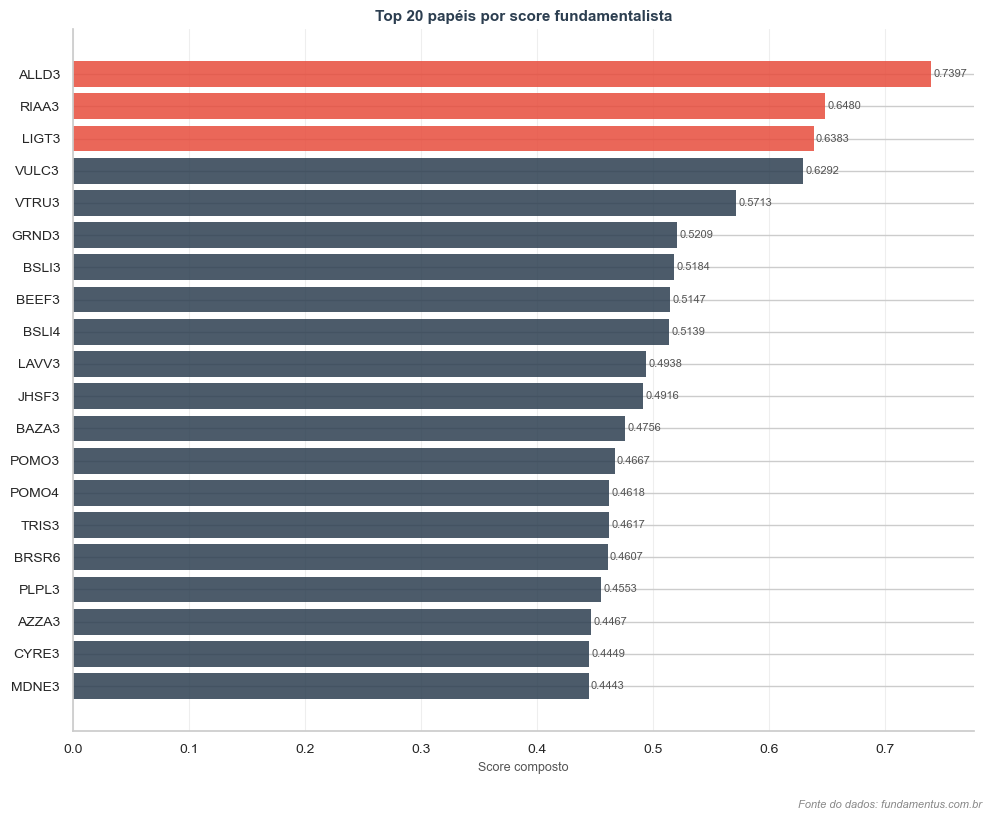

In [50]:
fig, ax = plt.subplots(figsize=(10, 8))

cores = [COR_BARRA if i >= 3 else '#e74c3c' for i in range(20)]

ax.barh(
    top20.index[::-1],
    top20['score'][::-1],
    color=cores[::-1],
    alpha=0.85,
    edgecolor='none'
)

for i, (idx, row) in enumerate(top20[::-1].iterrows()):
    ax.text(
        row['score'] + 0.002,
        i,
        f"{row['score']:.4f}",
        va='center', fontsize=8, color='#555555'
    )

ax.set_xlabel('Score composto', **FONTE_EIXO)
ax.set_title('Top 20 papéis por score fundamentalista',
             **FONTE_TITULO)
ax.xaxis.grid(True, color=COR_GRID, linewidth=0.8)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')

fig.text(0.99, -0.02, 'Fonte do dados: fundamentus.com.br',
         fontsize=8, color='#888888', style='italic', ha='right')

plt.tight_layout()
plt.show()

## 6. Análise Setorial dos Candidatos

Após o ranqueamento, analiso a distribuição setorial dos 108 papéis
selecionados. Essa etapa responde a uma pergunta relevante: o funil de
critérios favorece algum setor em particular, ou os candidatos estão
distribuídos de forma diversificada entre os setores da B3?

A concentração setorial é uma informação importante para quem utiliza
um screener como ponto de partida para análise. Um portfólio construído
exclusivamente a partir de papéis de um único setor carrega riscos
sistêmicos que os indicadores fundamentalistas individuais não capturam.

Para obter o setor de cada papel, utilizo a função `get_papel()` da
biblioteca `fundamentus`, que retorna informações cadastrais detalhadas
incluindo o setor de atuação de cada empresa.

### 6.1 Coleta dos Setores

In [33]:
df_score.sort_values('score', ascending=False).head(20).index

Index(['ALLD3', 'RIAA3', 'LIGT3', 'VULC3', 'VTRU3', 'GRND3', 'BSLI3', 'BEEF3',
       'BSLI4', 'LAVV3', 'JHSF3', 'BAZA3', 'POMO3', 'POMO4', 'TRIS3', 'BRSR6',
       'PLPL3', 'AZZA3', 'CYRE3', 'MDNE3'],
      dtype='str', name='papel')

In [53]:
tickers = list(df_score.sort_values('score', ascending=False).head(20).index)
df_detalhes = fundamentus.get_papel(tickers)
df_detalhes

2026-06-12 21:01:18,807 [detalhes.get_papel] INFO: detalhes: call: get..._list()
2026-06-12 21:01:18,809 [detalhes.get_detalhes_list] INFO: get list: [Papel: ALLD3]
2026-06-12 21:01:18,873 [detalhes.get_detalhes_list] INFO: get list: [Papel: RIAA3]
2026-06-12 21:01:18,911 [detalhes.get_detalhes_list] INFO: get list: [Papel: LIGT3]
2026-06-12 21:01:18,996 [detalhes.get_detalhes_list] INFO: get list: [Papel: VULC3]
2026-06-12 21:01:19,034 [detalhes.get_detalhes_list] INFO: get list: [Papel: VTRU3]
2026-06-12 21:01:19,072 [detalhes.get_detalhes_list] INFO: get list: [Papel: GRND3]
2026-06-12 21:01:19,123 [detalhes.get_detalhes_list] INFO: get list: [Papel: BSLI3]
2026-06-12 21:01:19,178 [detalhes.get_detalhes_list] INFO: get list: [Papel: BEEF3]
2026-06-12 21:01:19,228 [detalhes.get_detalhes_list] INFO: get list: [Papel: BSLI4]
2026-06-12 21:01:19,568 [detalhes.get_detalhes_list] INFO: get list: [Papel: LAVV3]
2026-06-12 21:01:21,446 [detalhes.get_detalhes_list] INFO: get list: [Papel: JH

,Tipo,Empresa,Setor,Subsetor,Cotacao,Data_ult_cot,Min_52_sem,Max_52_sem,Vol_med_2m,Valor_de_mercado,...,Lucro_Liquido_12m,Receita_Liquida_3m,EBIT_3m,Lucro_Liquido_3m,Cart_de_Credito,Depositos,Result_Int_Financ_12m,Rec_Servicos_12m,Result_Int_Financ_3m,Rec_Servicos_3m
ALLD3,ON NM,ALLIED ON NM,Comércio,Eletrodomésticos,5.42,2026-06-11,4.94,8.24,2185740,520112000,...,342338000,1159440000,47329000,24687000,NaN,NaN,NaN,NaN,NaN,NaN
AZZA3,ON,AZZAS 2154 ON,Comércio,"Tecidos, Vestuário e Calçados",17.51,2026-06-11,16.85,39.07,66521800,3615640000,...,832019000,2479520000,148626000,38596000,NaN,NaN,NaN,NaN,NaN,NaN
BAZA3,ON,BANCO DA AMAZONIA S.A. ON,Intermediários Financeiros,Bancos,62.25,2026-06-11,56.41,75.47,597772,3489610000,...,845498000,NaN,NaN,47537000,0,0,73109000,855256000,-241353000,197302000
BEEF3,ON NM,Minerva ON NM,Alimentos Processados,Carnes e Derivados,3.78,2026-06-11,3.50,7.18,70776100,3782040000,...,711778000,13409400000,851993000,57658000,NaN,NaN,NaN,NaN,NaN,NaN
BRSR6,PNB,BANRISUL S/A PNB,Intermediários Financeiros,Bancos,15.02,2026-06-11,9.71,18.86,36732600,6142790000,...,1584360000,NaN,NaN,221407000,0,0,6226140000,1026580000,1623520000,263873000
BSLI3,ON,BRB ON,Intermediários Financeiros,Bancos,3.35,2026-06-11,3.33,10.54,146168,1628710000,...,698331000,NaN,NaN,272858000,0,0,3408270000,251611000,937540000,60448000
BSLI4,ON,BRB ON,Intermediários Financeiros,Bancos,3.58,2026-06-11,3.34,11.48,138886,1740530000,...,698331000,NaN,NaN,272858000,0,0,3408270000,251611000,937540000,60448000
CYRE3,PN,CYRELA BRAZIL REALTY PN,Construção Civil,Incorporações,21.10,2026-06-11,18.76,32.00,167940000,9638480000,...,1975900000,2025030000,255313000,296776000,NaN,NaN,NaN,NaN,NaN,NaN
GRND3,ON,GRENDENE SA ON,"Tecidos, Vestuário e Calçados",Calçados,3.99,2026-06-11,3.49,4.95,16903400,3599620000,...,633582000,533843000,54966000,102138000,NaN,NaN,NaN,NaN,NaN,NaN
JHSF3,ON NM,JHSF Part ON NM,Construção Civil,Incorporações,10.93,2026-06-11,4.63,14.03,73347200,7473450000,...,1915400000,537661000,211533000,369687000,NaN,NaN,NaN,NaN,NaN,NaN


In [56]:
df_detalhes.columns

Index(['Tipo', 'Empresa', 'Setor', 'Subsetor', 'Cotacao', 'Data_ult_cot',
       'Min_52_sem', 'Max_52_sem', 'Vol_med_2m', 'Valor_de_mercado',
       'Valor_da_firma', 'Ult_balanco_processado', 'Nro_Acoes', 'PL', 'PVP',
       'PEBIT', 'PSR', 'PAtivos', 'PCap_Giro', 'PAtiv_Circ_Liq', 'Div_Yield',
       'EV_EBITDA', 'EV_EBIT', 'Cres_Rec_5a', 'LPA', 'VPA', 'Marg_Bruta',
       'Marg_EBIT', 'Marg_Liquida', 'EBIT_Ativo', 'ROIC', 'ROE',
       'Liquidez_Corr', 'Div_Liq_Patrim', 'Giro_Ativos', 'Ativo',
       'Disponibilidades', 'Ativo_Circulante', 'Div_Bruta', 'Div_Liquida',
       'Patrim_Liq', 'Receita_Liquida_12m', 'EBIT_12m', 'Lucro_Liquido_12m',
       'Receita_Liquida_3m', 'EBIT_3m', 'Lucro_Liquido_3m', 'Cart_de_Credito',
       'Depositos', 'Result_Int_Financ_12m', 'Rec_Servicos_12m',
       'Result_Int_Financ_3m', 'Rec_Servicos_3m'],
      dtype='str')

In [36]:
df_detalhes.Setor

ALLD3                         Comércio
AZZA3                         Comércio
BAZA3       Intermediários Financeiros
BEEF3            Alimentos Processados
BRSR6       Intermediários Financeiros
BSLI3       Intermediários Financeiros
BSLI4       Intermediários Financeiros
CYRE3                 Construção Civil
GRND3    Tecidos, Vestuário e Calçados
JHSF3                 Construção Civil
LAVV3                 Construção Civil
LIGT3                 Energia Elétrica
MDNE3                 Construção Civil
PLPL3                 Construção Civil
POMO3           Material de Transporte
POMO4           Material de Transporte
RIAA3                         Comércio
TRIS3                 Construção Civil
VTRU3                         Diversos
VULC3    Tecidos, Vestuário e Calçados
Name: Setor, dtype: str

In [57]:
df_detalhes = df_detalhes[['Setor']].copy()
df_detalhes.index.name = 'papel'

df_detalhes

,Setor
papel,
ALLD3,Comércio
AZZA3,Comércio
BAZA3,Intermediários Financeiros
BEEF3,Alimentos Processados
BRSR6,Intermediários Financeiros
BSLI3,Intermediários Financeiros
BSLI4,Intermediários Financeiros
CYRE3,Construção Civil
GRND3,"Tecidos, Vestuário e Calçados"


### 6.2 Distribuição Setorial do Top 20

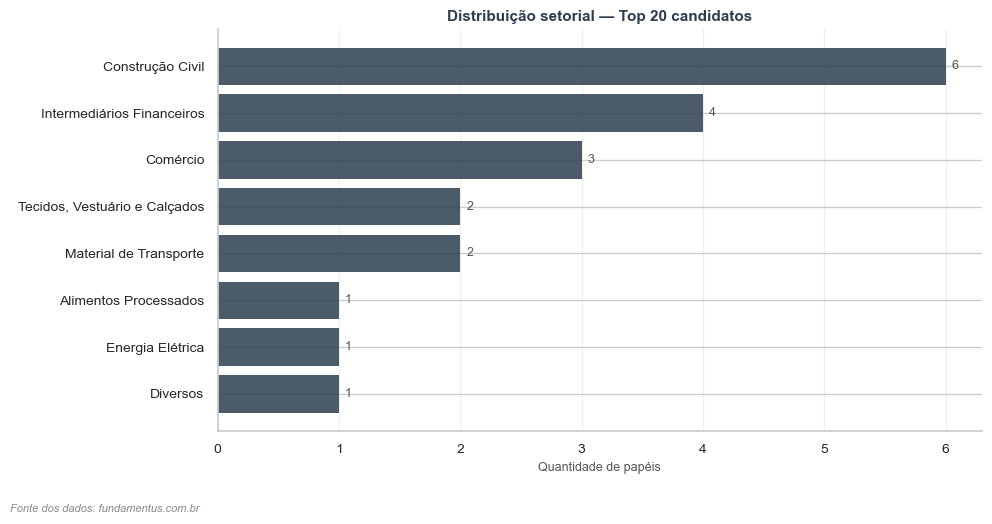

In [58]:
contagem_setores = df_detalhes['Setor'].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))

barras = ax.barh(
    contagem_setores.index[::-1],
    contagem_setores.values[::-1],
    color=COR_BARRA, alpha=0.85, edgecolor='none'
)

for i, v in enumerate(contagem_setores.values[::-1]):
    ax.text(v + 0.05, i, str(v), va='center', fontsize=9, color='#555555')

ax.set_xlabel('Quantidade de papéis', **FONTE_EIXO)
ax.set_title('Distribuição setorial — Top 20 candidatos',
             **FONTE_TITULO)
ax.xaxis.grid(True, color=COR_GRID, linewidth=0.8)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')

fig.text(0.01, -0.04, 'Fonte dos dados: fundamentus.com.br',
         fontsize=8, color='#888888', style='italic')

plt.tight_layout()
plt.show()

### 6.3 Score Médio por Setor

Além da contagem, analiso o score médio dos papéis por setor. Essa visão
complementa a contagem: um setor com poucos representantes mas score médio
elevado pode ser tão relevante quanto um setor com muitos candidatos de
qualidade mediana.

In [59]:
df_top20 = df_score.sort_values('score', ascending=False).head(20).copy()
df_top20 = df_top20.join(df_detalhes)

score_setor = (
    df_top20.groupby('Setor')['score']
    .agg(media='mean', quantidade='count')
    .sort_values('media', ascending=False)
    .round(4)
)

score_setor

,media,quantidade
Setor,,
Energia Elétrica,0.6383,1
Comércio,0.6115,3
"Tecidos, Vestuário e Calçados",0.5751,2
Diversos,0.5713,1
Alimentos Processados,0.5147,1
Intermediários Financeiros,0.4921,4
Construção Civil,0.4653,6
Material de Transporte,0.4643,2


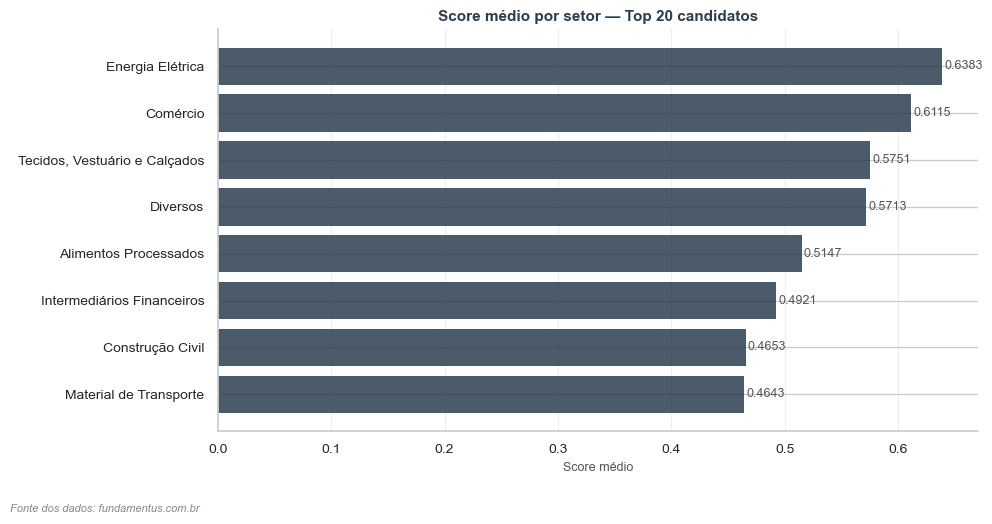

In [60]:
fig, ax = plt.subplots(figsize=(10, 5))

barras = ax.barh(
    score_setor.index[::-1],
    score_setor['media'][::-1],
    color=COR_BARRA, alpha=0.85, edgecolor='none'
)

for i, v in enumerate(score_setor['media'][::-1]):
    ax.text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=9, color='#555555')

ax.set_xlabel('Score médio', **FONTE_EIXO)
ax.set_title('Score médio por setor — Top 20 candidatos',
             **FONTE_TITULO)
ax.xaxis.grid(True, color=COR_GRID, linewidth=0.8)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')

fig.text(0.01, -0.04, 'Fonte dos dados: fundamentus.com.br',
         fontsize=8, color='#888888', style='italic')

plt.tight_layout()
plt.show()

## 7. Conclusão e Considerações Finais

### 7.1 Síntese do Projeto

Neste projeto, desenvolvi um pipeline completo de análise fundamentalista
aplicado ao mercado de ações brasileiro, utilizando exclusivamente ferramentas
do ecossistema Python. A partir de um universo bruto de 994 papéis listados
na B3, conduzi o processo em quatro etapas principais: coleta e inspeção dos
dados, limpeza e tratamento de inconsistências, aplicação progressiva de um
funil de critérios fundamentalistas e ranqueamento por score composto.

O funil reduziu o universo de forma expressiva em cada etapa:

| Etapa                        | Papéis restantes |
|------------------------------|-----------------|
| Universo bruto coletado      | 994             |
| Após limpeza (liquidez + PL) | 357             |
| Após critério P/L            | 206             |
| Após critério P/VP           | 192             |
| Após critério ROE            | 150             |
| Após critério Liquidez       | 108             |

Ao final do processo, 108 papéis atenderam a todos os critérios estabelecidos.
O ranqueamento por score composto, construído a partir da normalização
ponderada de ROE, P/L, P/VP e Dividend Yield, apontou ALLD3 como o papel
com o melhor conjunto de fundamentos dentro do universo filtrado, com score
de 0.7397, seguido por RIAA3 (0.6480) e LIGT3 (0.6383).

### 7.2 Análise Setorial

A distribuição setorial do Top 20 revelou que a Construção Civil foi o setor
com maior representação, com 6 papéis selecionados. No entanto, ao analisar
o score médio por setor, o quadro se inverte: Energia Elétrica liderou com
score médio de 0.6383, seguido por Comércio (0.6115) e Tecidos, Vestuário e
Calçados (0.5751), todos com menos representantes. Construção Civil, apesar
da maior quantidade, registrou o menor score médio entre os setores presentes
no Top 20 (0.4653).

Esse contraste sugere que o funil de critérios não favoreceu um único setor,
mas que a Construção Civil possui um número maior de empresas que satisfazem
os limiares mínimos adotados, ainda que com fundamentos menos destacados em
termos relativos.

### 7.3 Limitações e Considerações

Algumas limitações importantes devem ser consideradas na interpretação dos
resultados deste projeto.

Os dados coletados representam um único momento no tempo. Indicadores
fundamentalistas variam ao longo dos trimestres, e a análise pode produzir
resultados distintos em datas diferentes de execução. Isso é uma característica
estrutural da fonte utilizada, o site Fundamentus, que disponibiliza apenas
snapshots do estado atual de cada papel, sem histórico de múltiplos.

Os limiares adotados no funil são referências amplamente utilizadas na
literatura de value investing, mas não são universais. Ajustes nesses
parâmetros alteram substancialmente o conjunto de candidatos, e a escolha
dos pesos no score composto reflete uma preferência analítica particular,
não uma verdade objetiva sobre o valor das empresas.

Durante a análise, identifiquei que a biblioteca `fundamentus` oferece duas
interfaces distintas: `get_resultado_raw()`, utilizada neste projeto para
os múltiplos de mercado, e `get_papel()`, utilizada na seção de análise
setorial. Esta segunda interface entrega um conjunto consideravelmente mais
rico de informações, incluindo dados de balanço absolutos como receita
líquida, EBIT, lucro líquido e dívida bruta, além de indicadores adicionais
como giro de ativos e margem bruta, que não estão disponíveis no retorno
do `get_resultado_raw()`. A incorporação dessas variáveis ao score composto
representa uma dimensão analítica que este projeto não explorou e que
constitui uma limitação do modelo de ranqueamento adotado.

Por fim, os resultados deste notebook não constituem recomendação de compra
ou venda de nenhum ativo. O projeto tem finalidade exclusivamente educacional
e demonstrativa.